# Additions — Group 22

This notebook adds 4 new analyses aligned with the professor requirements:
1. **Ranking Analysis (Precision@K, Lift@K, Recall@K)** — how well each model ranks the most suspicious providers
2. **Precision-Recall Curves** — all models overlaid on one plot (both datasets)
3. **Cost-Sensitive Threshold Analysis** — optimal threshold using real-world fraud costs (both datasets)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_auc_score, auc, confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import os

COST_FN = 50_000
COST_FP = 500
DROP_COLS = ['fraud_label', 'Rndrng_NPI', 'Rndrng_Prvdr_City',
             'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type']
COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728',
          '#9467bd','#8c564b','#e377c2','#17becf']

def precision_at_k(y_true, y_scores, k):
    top_k = np.argsort(np.array(y_scores))[::-1][:k]
    return np.array(y_true)[top_k].mean()

def train_all_models(X_train, y_train, X_test, y_test, tag=''):
    """Train all 8 models and return dict of probabilities."""
    spw = (y_train == 0).sum() / (y_train == 1).sum()
    msl = 5 if len(X_train) < 5000 else 50
    print(f'  [{tag}] scale_pos_weight={spw:.1f} | min_samples_leaf={msl}')

    lr = Pipeline([('scaler', StandardScaler()),
                   ('clf', LogisticRegression(class_weight='balanced', C=0.1,
                                              solver='liblinear', random_state=42))])
    lr.fit(X_train, y_train)

    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample',
                                 max_depth=8, min_samples_leaf=msl,
                                 max_features='sqrt', n_jobs=-1, random_state=42)
    rf.fit(X_train, y_train)

    smote_rf = ImbPipeline([
        ('smote', SMOTE(sampling_strategy=0.5 if msl==5 else 0.1, random_state=42, k_neighbors=3)),
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=10,
                                       max_features='sqrt', min_samples_leaf=msl,
                                       n_jobs=-1, random_state=42))
    ])
    smote_rf.fit(X_train, y_train)

    brf = BalancedRandomForestClassifier(n_estimators=200, max_depth=10,
                                          sampling_strategy='auto', replacement=True,
                                          bootstrap=True, n_jobs=-1, random_state=42)
    brf.fit(X_train, y_train)

    xgb = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=4,
                         min_child_weight=3, gamma=1, reg_alpha=1, reg_lambda=2,
                         subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                         early_stopping_rounds=50, random_state=42,
                         n_jobs=-1, eval_metric='aucpr')
    xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    smote = SMOTE(sampling_strategy=0.5 if msl==5 else 0.2, random_state=42, k_neighbors=3)
    Xs, ys = smote.fit_resample(X_train, y_train)
    xgb_smote = XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=4,
                               min_child_weight=5, gamma=1, subsample=0.8,
                               colsample_bytree=0.8, reg_alpha=1, reg_lambda=2,
                               early_stopping_rounds=50, random_state=42,
                               n_jobs=-1, eval_metric='aucpr')
    xgb_smote.fit(Xs, ys, eval_set=[(X_test, y_test)], verbose=False)

    imp_xgb = XGBClassifier(objective='binary:logistic',
                             n_estimators=800 if msl==5 else 2000,
                             learning_rate=0.01, max_depth=4, min_child_weight=5,
                             gamma=1, subsample=0.8, colsample_bytree=0.8,
                             reg_alpha=1, reg_lambda=4, scale_pos_weight=spw,
                             eval_metric='aucpr', early_stopping_rounds=80,
                             random_state=42, n_jobs=-1)
    imp_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    p_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]
    p_brf       = brf.predict_proba(X_test)[:, 1]
    w_xgb = 0.6 if msl==5 else 0.9
    w_brf = 1 - w_xgb

    probs = {
        'Logistic Regression': lr.predict_proba(X_test)[:, 1],
        'Random Forest':       rf.predict_proba(X_test)[:, 1],
        'SMOTE + RF':          smote_rf.predict_proba(X_test)[:, 1],
        'Balanced RF':         p_brf,
        'XGBoost (Base)':      xgb.predict_proba(X_test)[:, 1],
        'SMOTE + XGBoost':     p_xgb_smote,
        'Improved XGBoost':    imp_xgb.predict_proba(X_test)[:, 1],
        f'Ensemble (XGB{w_xgb}+BRF{w_brf})': w_xgb * p_xgb_smote + w_brf * p_brf,
    }
    return probs, imp_xgb, brf

print('Setup complete.')

Setup complete.


---
## PART 0 — Ranking Analysis (Both Datasets)

The professor specifically requires evaluating **how well the model ranks the most suspicious providers**.
This section computes for each model:
- **Precision@K** — what fraction of the top-K scored providers are truly fraud
- **Lift@K** — how many times better than random the model is at top-K
- **Cumulative Recall@K** — what fraction of ALL fraud cases are captured in the top-K

These directly answer: *"Is the model useful for an investigator who can only review N cases per week?"*

In [2]:
# ============================================================
# RANKING ANALYSIS HELPER
# ============================================================
def ranking_analysis(probs_dict, y_test, dataset_name, iso_scores=None):
    K_VALUES = [k for k in [10, 20, 50, 100, 200, 500] if k <= len(y_test)]
    y_arr = np.array(y_test)
    total_fraud = y_arr.sum()
    baseline_rate = y_arr.mean()

    all_models = dict(probs_dict)
    if iso_scores is not None:
        all_models["Isolation Forest"] = iso_scores

    print(f"\n" + "="*70)
    print(f"  RANKING ANALYSIS - {dataset_name}")
    print(f"  Total fraud: {total_fraud} | Baseline rate: {baseline_rate:.4f}")
    print("="*70)

    rows = []
    for name, probs in all_models.items():
        row = {"Model": name}
        sorted_idx = np.argsort(probs)[::-1]
        for k in K_VALUES:
            top_k = sorted_idx[:k]
            pk   = y_arr[top_k].mean()
            lift = pk / baseline_rate if baseline_rate > 0 else 0
            rec  = y_arr[top_k].sum() / total_fraud if total_fraud > 0 else 0
            row[f"P@{k}"]    = round(pk,   4)
            row[f"Lift@{k}"] = round(lift, 2)
            row[f"Rec@{k}"]  = round(rec,  4)
        row["AUPRC"] = round(average_precision_score(y_test, probs), 4)
        rows.append(row)

    df_rank = pd.DataFrame(rows).set_index("Model")
    pk_cols  = [c for c in df_rank.columns if c.startswith("P@")]
    lft_cols = [c for c in df_rank.columns if c.startswith("Lift@")]
    rec_cols = [c for c in df_rank.columns if c.startswith("Rec@")]

    print("\nPrecision@K:")
    print(df_rank[pk_cols + ["AUPRC"]].to_string())
    print("\nLift@K (times better than random):")
    print(df_rank[lft_cols].to_string())
    print("\nCumulative Recall@K (fraction of all fraud caught):")
    print(df_rank[rec_cols].to_string())

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Ranking Performance - {dataset_name}", fontsize=14, fontweight="bold")
    cmap = plt.cm.tab10(np.linspace(0, 1, len(all_models)))
    n = len(all_models)
    w = 0.8 / n

    for idx, (name, row) in enumerate(df_rank.iterrows()):
        x = np.arange(len(pk_cols)) + idx * w
        axes[0].bar(x, row[pk_cols].values, width=w, color=cmap[idx], label=name, alpha=0.85)
    axes[0].axhline(y=baseline_rate, color="gray", linestyle="--", linewidth=1.5, label=f"Random ({baseline_rate:.4f})")
    axes[0].set_xticks(np.arange(len(pk_cols)) + w*n/2)
    axes[0].set_xticklabels([c.replace("P@","K=") for c in pk_cols])
    axes[0].set_title("Precision@K"); axes[0].set_ylabel("Precision")
    axes[0].legend(fontsize=6, loc="upper right"); axes[0].grid(True, alpha=0.3, axis="y")

    for idx, (name, row) in enumerate(df_rank.iterrows()):
        x = np.arange(len(lft_cols)) + idx * w
        axes[1].bar(x, row[lft_cols].values, width=w, color=cmap[idx], label=name, alpha=0.85)
    axes[1].axhline(y=1.0, color="gray", linestyle="--", linewidth=1.5, label="Random (1.0x)")
    axes[1].set_xticks(np.arange(len(lft_cols)) + w*n/2)
    axes[1].set_xticklabels([c.replace("Lift@","K=") for c in lft_cols])
    axes[1].set_title("Lift@K"); axes[1].set_ylabel("Lift")
    axes[1].legend(fontsize=6, loc="upper right"); axes[1].grid(True, alpha=0.3, axis="y")

    k_nums = [int(c.replace("Rec@","")) for c in rec_cols]
    for idx, (name, row) in enumerate(df_rank.iterrows()):
        axes[2].plot(k_nums, row[rec_cols].values, marker="o", color=cmap[idx], label=name, linewidth=2)
    random_rec = [min(k * baseline_rate, 1.0) for k in k_nums]
    axes[2].plot(k_nums, random_rec, color="gray", linestyle="--", linewidth=1.5, label="Random")
    axes[2].set_title("Cumulative Recall@K"); axes[2].set_ylabel("Recall")
    axes[2].set_xlabel("K (providers reviewed)"); axes[2].legend(fontsize=6)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    safe = dataset_name.lower().replace(" ","_")
    fname = f"../data/processed/ranking_analysis_{safe}.png"
    os.makedirs("../data/processed", exist_ok=True)
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")
    return df_rank

print("Ranking analysis helper defined.")

Ranking analysis helper defined.


---
## PART A — Original Imbalanced Dataset

In [5]:
# Load original dataset
df_orig = pd.read_csv('../data/processed/medicare_labeled.csv')
X_orig = df_orig.drop(columns=[c for c in DROP_COLS if c in df_orig.columns])
X_orig = X_orig.select_dtypes(include=['number', 'bool'])
y_orig = df_orig['fraud_label']
X_tr_o, X_te_o, y_tr_o, y_te_o = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig
)
print(f'Original — Train: {len(X_tr_o):,} | Test: {len(X_te_o):,} | Fraud in test: {y_te_o.sum()}')

print('Training all models on original data (this may take a few minutes)...')
probs_o, imp_xgb_o, brf_o = train_all_models(X_tr_o, y_tr_o, X_te_o, y_te_o, tag='Original')
print('Done!')

Original — Train: 1,007,474 | Test: 251,869 | Fraud in test: 37
Training all models on original data (this may take a few minutes)...
  [Original] scale_pos_weight=6715.5 | min_samples_leaf=50
Done!


### A1 — Precision-Recall Curves (Original Dataset)

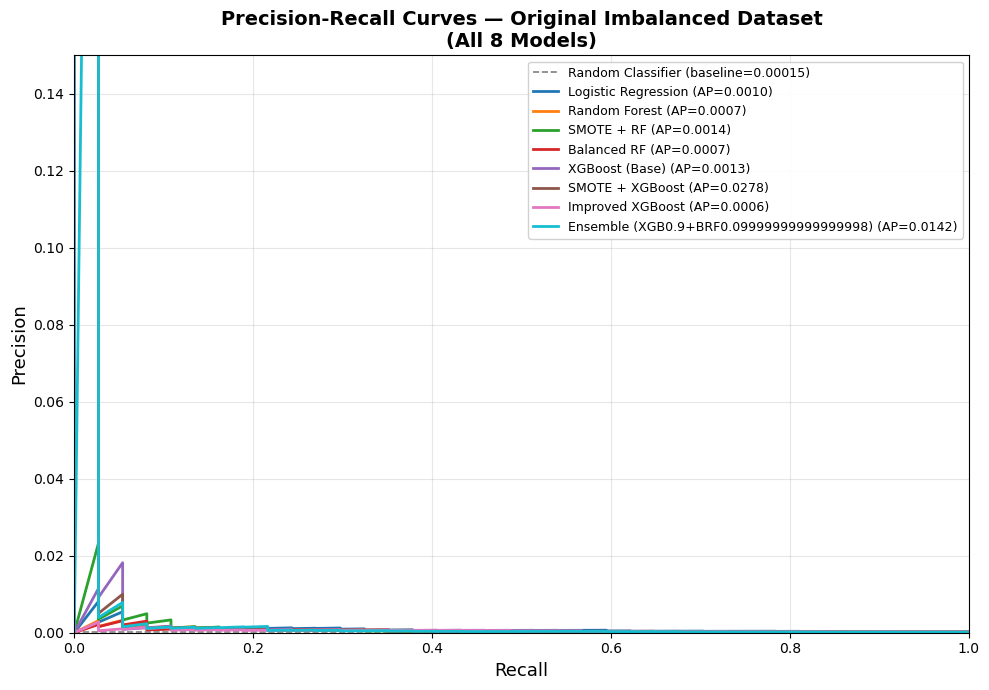

Saved: pr_curves_original.png


In [ ]:
baseline_o = y_te_o.mean()
fig, ax = plt.subplots(figsize=(10, 7))
ax.axhline(y=baseline_o, color='gray', linestyle='--', linewidth=1.2,
           label=f'Random Classifier (baseline={baseline_o:.5f})')

for (name, probs), color in zip(probs_o.items(), COLORS):
    prec, rec, _ = precision_recall_curve(y_te_o, probs)
    ap = average_precision_score(y_te_o, probs)
    ax.plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP={ap:.4f})')

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curves — Original Imbalanced Dataset\n(All 8 Models)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 0.15])  # zoom y-axis for readability
ax.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs('../data/processed', exist_ok=True)
plt.savefig('../data/processed/pr_curves_original.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pr_curves_original.png')

### A3 — Cost-Sensitive Threshold Analysis (Original Dataset)

=== Cost-Sensitive Analysis — Original Dataset ===
Assumptions: False Negative=$50,000 | False Positive=$500
Default threshold (0.50) cost : $2,361,000
Optimal threshold  (0.685) cost : $1,800,000
Savings: $561,000
Precision @ optimal: 1.0000 | Recall: 0.0270


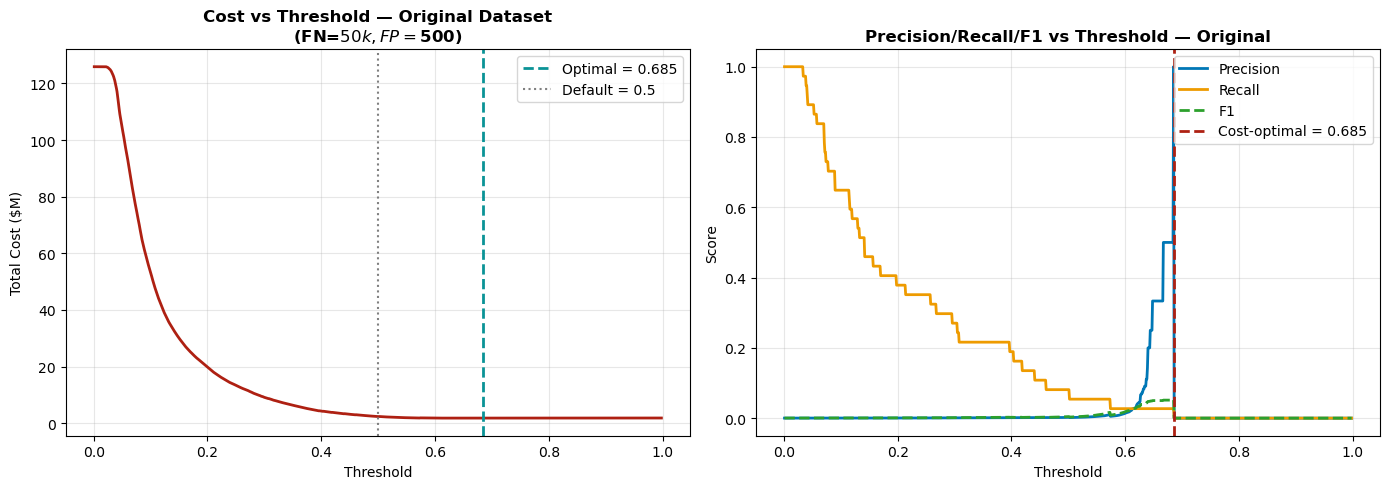

Saved: cost_analysis_original.png


In [ ]:
print('=== Cost-Sensitive Analysis — Original Dataset ===')
print(f'Assumptions: False Negative=${COST_FN:,} | False Positive=${COST_FP:,}')

best_probs_o = probs_o[best_name_o]
thresholds   = np.arange(0.001, 0.999, 0.001)
costs_o, precs_o, recs_o, f1s_o = [], [], [], []

for th in thresholds:
    preds = (best_probs_o >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te_o, preds).ravel()
    costs_o.append(fn * COST_FN + fp * COST_FP)
    p = tp/(tp+fp) if (tp+fp)>0 else 0
    r = tp/(tp+fn) if (tp+fn)>0 else 0
    precs_o.append(p); recs_o.append(r)
    f1s_o.append(2*p*r/(p+r) if (p+r)>0 else 0)

opt_idx_o = np.argmin(costs_o)
opt_th_o  = thresholds[opt_idx_o]
cost_05_o = costs_o[np.argmin(np.abs(thresholds - 0.5))]
print(f'Default threshold (0.50) cost : ${cost_05_o:,.0f}')
print(f'Optimal threshold  ({opt_th_o:.3f}) cost : ${costs_o[opt_idx_o]:,.0f}')
print(f'Savings: ${cost_05_o - costs_o[opt_idx_o]:,.0f}')
print(f'Precision @ optimal: {precs_o[opt_idx_o]:.4f} | Recall: {recs_o[opt_idx_o]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thresholds, [c/1e6 for c in costs_o], color='#AE2012', linewidth=2)
axes[0].axvline(x=opt_th_o, color='#0A9396', linestyle='--', linewidth=2,
                label=f'Optimal = {opt_th_o:.3f}')
axes[0].axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, label='Default = 0.5')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Total Cost ($M)')
axes[0].set_title('Cost vs Threshold — Original Dataset\n(FN=$50k, FP=$500)', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(thresholds, precs_o, color='#0077B6', linewidth=2, label='Precision')
axes[1].plot(thresholds, recs_o,  color='#EE9B00', linewidth=2, label='Recall')
axes[1].plot(thresholds, f1s_o,   color='#2ca02c', linewidth=2, linestyle='--', label='F1')
axes[1].axvline(x=opt_th_o, color='#AE2012', linestyle='--', linewidth=2,
                label=f'Cost-optimal = {opt_th_o:.3f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('Precision/Recall/F1 vs Threshold — Original', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/cost_analysis_original.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cost_analysis_original.png')

### A4 — Ranking Analysis (Original Dataset)


  RANKING ANALYSIS - Original Imbalanced Dataset
  Total fraud: 37 | Baseline rate: 0.0001

Precision@K:
                                          P@10  P@20  P@50  P@100  P@200  P@500   AUPRC
Model                                                                                  
Logistic Regression                        0.0  0.00  0.00   0.00  0.005  0.004  0.0010
Random Forest                              0.0  0.00  0.00   0.00  0.000  0.002  0.0007
SMOTE + RF                                 0.0  0.00  0.02   0.01  0.005  0.004  0.0014
Balanced RF                                0.0  0.00  0.00   0.00  0.000  0.002  0.0007
XGBoost (Base)                             0.0  0.00  0.00   0.01  0.010  0.004  0.0013
SMOTE + XGBoost                            0.1  0.05  0.02   0.01  0.010  0.004  0.0278
Improved XGBoost                           0.0  0.00  0.00   0.00  0.000  0.002  0.0006
Ensemble (XGB0.9+BRF0.09999999999999998)   0.1  0.05  0.02   0.01  0.005  0.004  0.0142
Isolation Fore

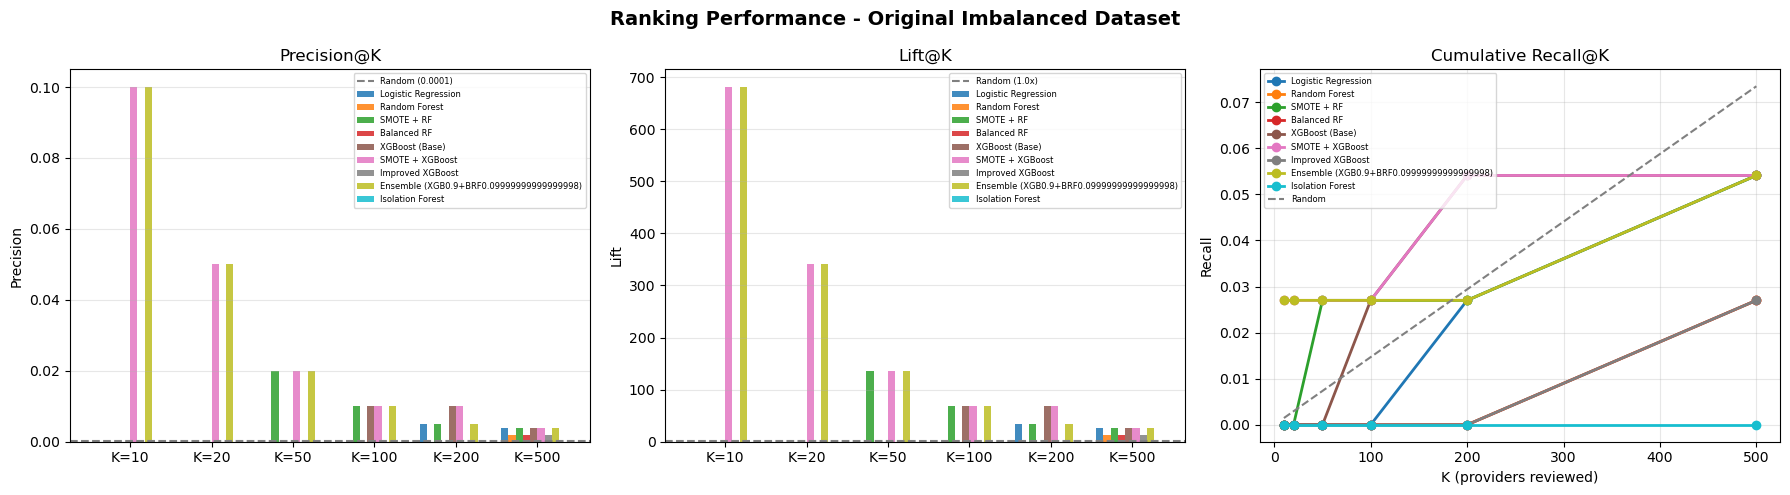

Saved: ../data/processed/ranking_analysis_original_imbalanced_dataset.png


In [ ]:
# Ranking Analysis — Original Dataset (runs after iso_scores_o is defined above)
df_rank_orig = ranking_analysis(
    probs_o, y_te_o,
    dataset_name="Original Imbalanced Dataset",
    iso_scores=iso_scores_o
)

---
## PART B — Undersampled Dataset

In [ ]:
df_bal = pd.read_csv('../data/processed/medicare_labeled_balanced.csv')
X_bal = df_bal.drop(columns=[c for c in DROP_COLS if c in df_bal.columns])
X_bal = X_bal.select_dtypes(include=['number', 'bool'])
y_bal = df_bal['fraud_label']
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)
print(f'Undersampled — Train: {len(X_tr_b)} | Test: {len(X_te_b)} | Fraud in test: {y_te_b.sum()}')

print('Training all models on undersampled data...')
probs_b, imp_xgb_b, brf_b = train_all_models(X_tr_b, y_tr_b, X_te_b, y_te_b, tag='Undersampled')
print('Done!')

Undersampled — Train: 1645 | Test: 412 | Fraud in test: 37
Training all models on undersampled data...
  [Undersampled] scale_pos_weight=10.0 | min_samples_leaf=5
Done!


### B1 — Precision-Recall Curves (Undersampled Dataset)

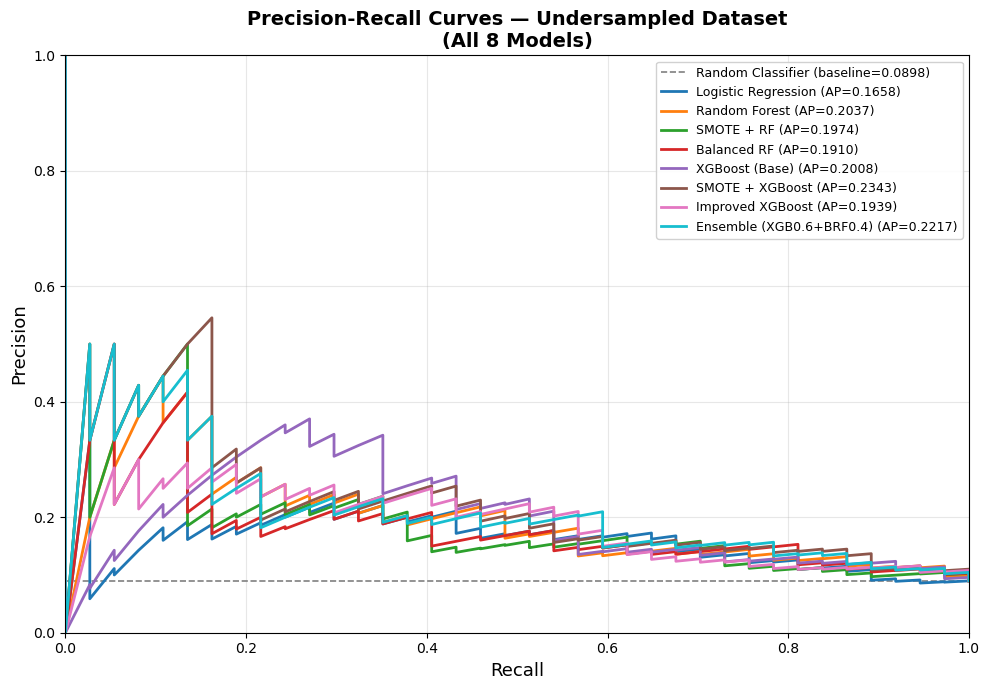

Saved: pr_curves_undersampled.png


In [ ]:
baseline_b = y_te_b.mean()
fig, ax = plt.subplots(figsize=(10, 7))
ax.axhline(y=baseline_b, color='gray', linestyle='--', linewidth=1.2,
           label=f'Random Classifier (baseline={baseline_b:.4f})')

for (name, probs), color in zip(probs_b.items(), COLORS):
    prec, rec, _ = precision_recall_curve(y_te_b, probs)
    ap = average_precision_score(y_te_b, probs)
    ax.plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP={ap:.4f})')

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curves — Undersampled Dataset\n(All 8 Models)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/pr_curves_undersampled.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pr_curves_undersampled.png')

### B3 — Cost-Sensitive Threshold Analysis (Undersampled Dataset)

=== Cost-Sensitive Analysis — Undersampled Dataset ===
Assumptions: False Negative=$50,000 | False Positive=$500
Default threshold (0.50) cost : $1,462,000
Optimal threshold  (0.071) cost : $150,000
Savings: $1,312,000
Precision @ optimal: 0.1098 | Recall: 1.0000


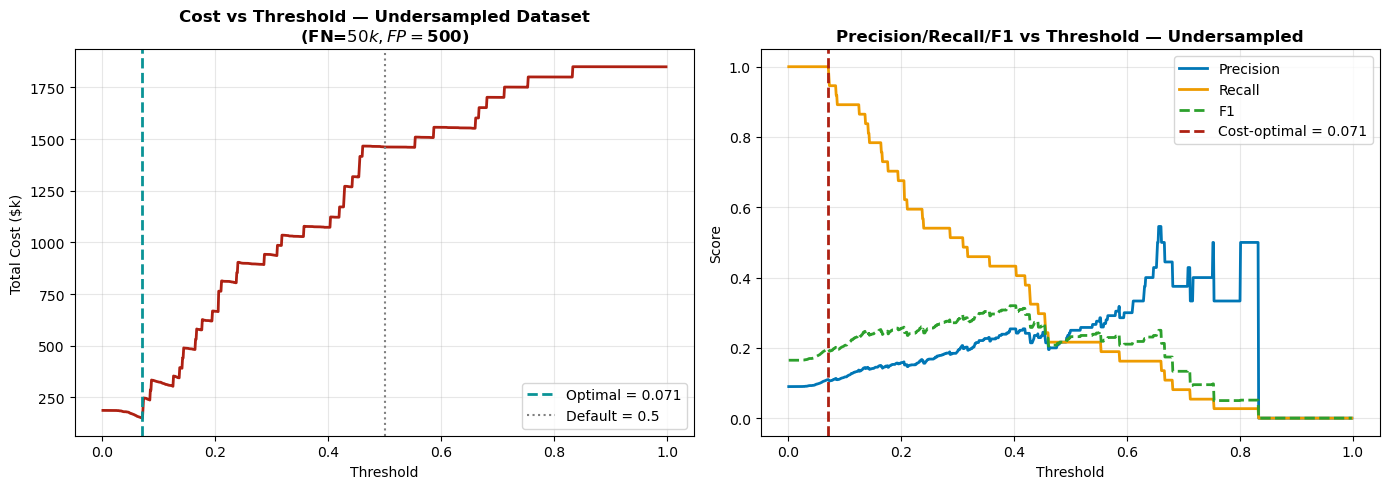

Saved: cost_analysis_undersampled.png


In [ ]:
print('=== Cost-Sensitive Analysis — Undersampled Dataset ===')
print(f'Assumptions: False Negative=${COST_FN:,} | False Positive=${COST_FP:,}')

best_probs_b = probs_b[best_name_b]
costs_b, precs_b, recs_b, f1s_b = [], [], [], []

for th in thresholds:
    preds = (best_probs_b >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te_b, preds).ravel()
    costs_b.append(fn * COST_FN + fp * COST_FP)
    p = tp/(tp+fp) if (tp+fp)>0 else 0
    r = tp/(tp+fn) if (tp+fn)>0 else 0
    precs_b.append(p); recs_b.append(r)
    f1s_b.append(2*p*r/(p+r) if (p+r)>0 else 0)

opt_idx_b = np.argmin(costs_b)
opt_th_b  = thresholds[opt_idx_b]
cost_05_b = costs_b[np.argmin(np.abs(thresholds - 0.5))]
print(f'Default threshold (0.50) cost : ${cost_05_b:,.0f}')
print(f'Optimal threshold  ({opt_th_b:.3f}) cost : ${costs_b[opt_idx_b]:,.0f}')
print(f'Savings: ${cost_05_b - costs_b[opt_idx_b]:,.0f}')
print(f'Precision @ optimal: {precs_b[opt_idx_b]:.4f} | Recall: {recs_b[opt_idx_b]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thresholds, [c/1e3 for c in costs_b], color='#AE2012', linewidth=2)
axes[0].axvline(x=opt_th_b, color='#0A9396', linestyle='--', linewidth=2,
                label=f'Optimal = {opt_th_b:.3f}')
axes[0].axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, label='Default = 0.5')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Total Cost ($k)')
axes[0].set_title('Cost vs Threshold — Undersampled Dataset\n(FN=$50k, FP=$500)', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(thresholds, precs_b, color='#0077B6', linewidth=2, label='Precision')
axes[1].plot(thresholds, recs_b,  color='#EE9B00', linewidth=2, label='Recall')
axes[1].plot(thresholds, f1s_b,   color='#2ca02c', linewidth=2, linestyle='--', label='F1')
axes[1].axvline(x=opt_th_b, color='#AE2012', linestyle='--', linewidth=2,
                label=f'Cost-optimal = {opt_th_b:.3f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('Precision/Recall/F1 vs Threshold — Undersampled', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/cost_analysis_undersampled.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cost_analysis_undersampled.png')

### B4 — Ranking Analysis (Undersampled Dataset)


  RANKING ANALYSIS - Undersampled Dataset
  Total fraud: 37 | Baseline rate: 0.0898

Precision@K:
                          P@10  P@20  P@50  P@100  P@200   AUPRC
Model                                                           
Logistic Regression        0.1  0.10  0.22   0.17  0.135  0.1658
Random Forest              0.4  0.30  0.24   0.18  0.140  0.2037
SMOTE + RF                 0.5  0.25  0.22   0.15  0.135  0.1974
Balanced RF                0.3  0.25  0.18   0.15  0.150  0.1910
XGBoost (Base)             0.0  0.20  0.26   0.20  0.135  0.2008
SMOTE + XGBoost            0.5  0.30  0.24   0.19  0.145  0.2343
Improved XGBoost           0.3  0.25  0.22   0.21  0.125  0.1939
Ensemble (XGB0.6+BRF0.4)   0.4  0.30  0.22   0.19  0.145  0.2217
Isolation Forest           0.3  0.35  0.20   0.13  0.105  0.1788

Lift@K (times better than random):
                          Lift@10  Lift@20  Lift@50  Lift@100  Lift@200
Model                                                                  
Logist

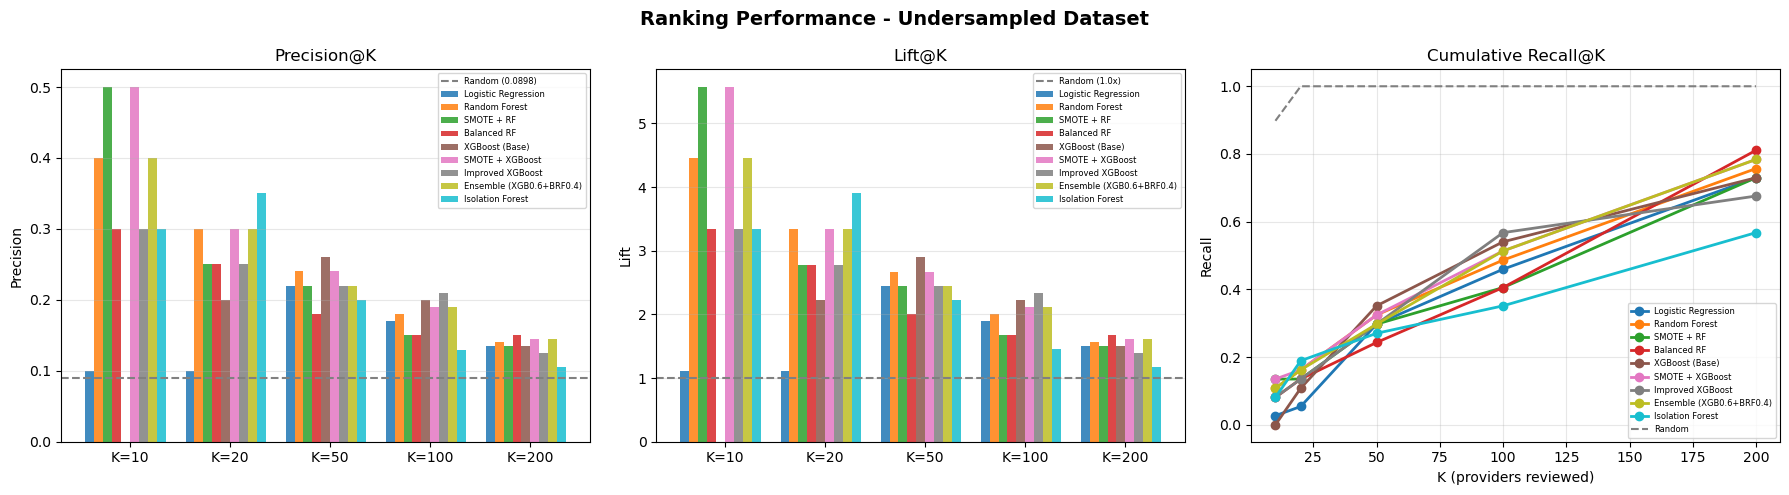

Saved: ../data/processed/ranking_analysis_undersampled_dataset.png


In [ ]:
# Ranking Analysis — Undersampled Dataset
df_rank_bal = ranking_analysis(
    probs_b, y_te_b,
    dataset_name="Undersampled Dataset",
    iso_scores=iso_scores_b
)